<a href="https://colab.research.google.com/github/Aaron-GMM/disciplina-PLN/blob/main/trabalho_analise_sentimentos_correto_com_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os
import pandas as pd
import re
import unicodedata
from transformers import AutoTokenizer
from datasets import Dataset
from sklearn.model_selection import train_test_split

In [ ]:
path = kagglehub.dataset_download(
    "fredericods/ptbr-sentiment-analysis-datasets"
)

100%|██████████| 877M/877M [00:12<00:00, 73.9MB/s]

Extracting files...


In [ ]:
import os
os.listdir(path)

['buscape.csv',
 'utlc_apps.csv',
 'b2w.csv',
 'concatenated.csv',
 'olist.csv',
 'utlc_movies.csv']

In [ ]:
df = pd.read_csv(os.path.join(path, "b2w.csv"))

df.info()

df.describe()

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132373 entries, 0 to 132372
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   original_index         132373 non-null  int64  
 1   review_text            132373 non-null  object 
 2   review_text_processed  132373 non-null  object 
 3   review_text_tokenized  132373 non-null  object 
 4   polarity               116058 non-null  float64
 5   rating                 132373 non-null  int64  
 6   kfold_polarity         132373 non-null  int64  
 7   kfold_rating           132373 non-null  int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 8.1+ MB


,original_index,review_text,review_text_processed,review_text_tokenized,polarity,rating,kfold_polarity,kfold_rating
0,11955,Bem macio e felpudo...recomendo. Preço imbatí...,bem macio e felpudo...recomendo. preco imbati...,"['bem', 'macio', 'felpudo', 'recomendo', 'prec...",1.0,4,1,1
1,35478,Produto excepcional! recomendo!!! inovador e ...,produto excepcional! recomendo!!! inovador e ...,"['produto', 'excepcional', 'recomendo', 'inova...",1.0,5,1,1
2,122760,recebi o produto antes do prazo mas veio com d...,recebi o produto antes do prazo mas veio com d...,"['recebi', 'produto', 'antes', 'do', 'prazo', ...",0.0,1,1,1
3,17114,Bom custo beneficio. Adequado para pessoas que...,bom custo beneficio. adequado para pessoas que...,"['bom', 'custo', 'beneficio', 'adequado', 'par...",1.0,5,1,1
4,19112,Além de higiênico tem o tamanho ideal. Só falt...,alem de higienico tem o tamanho ideal. so falt...,"['alem', 'de', 'higienico', 'tem', 'tamanho', ...",NaN,3,-1,1


In [ ]:
df = df.drop(columns=["review_text_processed", "review_text_tokenized"])

In [ ]:
df.columns

Index(['original_index', 'review_text', 'polarity', 'rating', 'kfold_polarity',
       'kfold_rating'],
      dtype='object')

In [ ]:
# removendso null e duplicadas
print(df.isnull().sum())

df = df.dropna(subset=["polarity"])
print("Duplicados:", df.duplicated(subset=["review_text"]).sum())

df = df.drop_duplicates(subset=["review_text"])

print(df["polarity"].value_counts())

df["label"] = df["polarity"].astype(int)

print(df["label"].value_counts())
df[["polarity", "label"]].head()

original_index        0
review_text           0
polarity          16315
rating                0
kfold_polarity        0
kfold_rating          0
dtype: int64
Duplicados: 2403
polarity
1.0    79226
0.0    34429
Name: count, dtype: int64
label
1    79226
0    34429
Name: count, dtype: int64


,polarity,label
0,1.0,1
1,1.0,1
2,0.0,0
3,1.0,1
5,1.0,1


In [ ]:
#preprocessamento
def preprocess(text):
    text = str(text).lower()

    # remove acentos
    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ASCII", "ignore").decode("utf-8")

    # remove links
    text = re.sub(r"http\S+|www\S+", "", text)

    # remove quebras de linha
    text = text.replace("\n", " ")

    # remove espaços repetidos
    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["review_text_processed"] = df["review_text"].apply(preprocess)

In [ ]:
df[["review_text","review_text_processed", "polarity", "label"]].head(40)

,review_text,review_text_processed,polarity,label
0,Bem macio e felpudo...recomendo. Preço imbatí...,bem macio e felpudo...recomendo. preco imbativ...,1.0,1
1,Produto excepcional! recomendo!!! inovador e ...,produto excepcional! recomendo!!! inovador e g...,1.0,1
2,recebi o produto antes do prazo mas veio com d...,recebi o produto antes do prazo mas veio com d...,0.0,0
3,Bom custo beneficio. Adequado para pessoas que...,bom custo beneficio. adequado para pessoas que...,1.0,1
5,"ótmo produto atendeu as expectativas, a entreg...","otmo produto atendeu as expectativas, a entreg...",1.0,1
6,"GOSTEI MUITO DO PRODUTO! TEM ÓTIMA QUALIDADE, ...","gostei muito do produto! tem otima qualidade, ...",1.0,1
7,"Adorei, entrega no prazo e produto conforme eu...","adorei, entrega no prazo e produto conforme eu...",1.0,1
8,Já é o segundo processador deste modelo que co...,ja e o segundo processador deste modelo que co...,1.0,1
9,Nao recebi!!! endereço para entrega : rua aug...,nao recebi!!! endereco para entrega : rua augu...,1.0,1
10,"Não compra este produto, pois o mesmo veio com...","nao compra este produto, pois o mesmo veio com...",0.0,0


In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1765,
    random_state=42,
    stratify=train_df["label"]
)

print(f"Treino: {len(train_df)} | Validação: {len(val_df)} | Teste: {len(test_df)}")


Treino: 74875 | Validação: 16049 | Teste: 22731


In [ ]:
# tokenização modelo 1
model_name_1 = "neuralmind/bert-base-portuguese-cased"

tokenizer_1 = AutoTokenizer.from_pretrained(model_name_1)

def tokenize_function_1(examples):
    return tokenizer_1(
        examples["review_text_processed"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset_1 = Dataset.from_pandas(train_df)
val_dataset_1 = Dataset.from_pandas(val_df)
test_dataset_1 = Dataset.from_pandas(test_df)

tokenized_train_1 = train_dataset_1.map(tokenize_function_1, batched=True)
tokenized_val_1 = val_dataset_1.map(tokenize_function_1, batched=True)
tokenized_test_1 = test_dataset_1.map(tokenize_function_1, batched=True)

if "__index_level_0__" in tokenized_train_1.column_names:
    tokenized_train_1 = tokenized_train_1.remove_columns(["__index_level_0__"])
    tokenized_val_1 = tokenized_val_1.remove_columns(["__index_level_0__"])
    tokenized_test_1 = tokenized_test_1.remove_columns(["__index_level_0__"])

tokenized_train_1.to_pandas().head()
tokenized_val_1.to_pandas().head()
tokenized_test_1.to_pandas().head()


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/74875 [00:00<?, ? examples/s]

Map:   0%|          | 0/16049 [00:00<?, ? examples/s]

Map:   0%|          | 0/22731 [00:00<?, ? examples/s]

,original_index,review_text,polarity,rating,kfold_polarity,kfold_rating,label,review_text_processed,input_ids,token_type_ids,attention_mask
0,122068,"Aparelho muito bom, bateria duradora, memoria ...",1.0,4,1,1,1,"aparelho muito bom, bateria duradora, memoria ...","[101, 11051, 785, 4062, 117, 7413, 3072, 5271,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,65143,"Ótimo, entrega super rápida. Adorei o produto,...",1.0,5,3,3,1,"otimo, entrega super rapida. adorei o produto,...","[101, 12512, 22280, 117, 9358, 1229, 6372, 328...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,15353,"Ótimo estojo, material de qualidade, bom acaba...",1.0,4,4,4,1,"otimo estojo, material de qualidade, bom acaba...","[101, 12512, 22280, 9466, 1286, 117, 3028, 125...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,126911,Adoramos!Perfeita para cozinhar no fogão de le...,1.0,4,7,7,1,adoramos!perfeita para cozinhar no fogao de le...,"[101, 2251, 20454, 106, 13420, 221, 13159, 222...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,2941,A lavadora faz o que promete. É muito simples ...,1.0,5,5,5,1,a lavadora faz o que promete. e muito simples ...,"[101, 123, 11348, 5271, 659, 146, 179, 19790, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [ ]:
# tokenização modelo 2
model_name_2 = "bert-base-multilingual-cased"

tokenizer_2 = AutoTokenizer.from_pretrained(model_name_2)

def tokenize_function_2(examples):
    return tokenizer_2(
        examples["review_text_processed"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset_2 = Dataset.from_pandas(train_df)
val_dataset_2 = Dataset.from_pandas(val_df)
test_dataset_2 = Dataset.from_pandas(test_df)

tokenized_train_2 = train_dataset_2.map(tokenize_function_2, batched=True)
tokenized_val_2 = val_dataset_2.map(tokenize_function_2, batched=True)
tokenized_test_2 = test_dataset_2.map(tokenize_function_2, batched=True)

if "__index_level_0__" in tokenized_train_2.column_names:
    tokenized_train_2 = tokenized_train_2.remove_columns(["__index_level_0__"])
    tokenized_val_2 = tokenized_val_2.remove_columns(["__index_level_0__"])
    tokenized_test_2 = tokenized_test_2.remove_columns(["__index_level_0__"])

tokenized_train_2.to_pandas().head()
tokenized_val_2.to_pandas().head()
tokenized_test_2.to_pandas().head()


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Map:   0%|          | 0/74875 [00:00<?, ? examples/s]

## Experimentos de Fine-Tuning
Tive problemas com o Tempo e o limite de execução utilizando a GPU e versão free do Colab então eu fiz que
cada resultado de treinamento é salvo em
um CSV assim que fica pronto. Se o Colab desconectar ou a cota de GPU acabar no meio do processo,  não perde o que já rodou ao reexecutar o notebook, os experimentos já concluídos são carregados em vez de retreinados por conta .
Experimento 4 mas  em vez de treinar o modelo completo 3 vezes
(2, 3 e 5 épocas) usando as ~75 mil amostras de treino inteiras a busca de número de épocas usa uma subamostra estratificada por rótulo do conjunto de treino.


## 1. Imports e configuração

In [ ]:
import gc
import inspect
import os
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo em uso: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Alterar tipo de ambiente de execução ")

_TA_PARAMS = inspect.signature(TrainingArguments.__init__).parameters
EVAL_STRATEGY_KEY = "eval_strategy" if "eval_strategy" in _TA_PARAMS else "evaluation_strategy"

## 2. Persistência dos resultados (cache resumível)

alguns resultados salvos para que o dados
sobreviva a quedas de sessão e  possamos a continuar de onde parou em outro dia ou em outra conta com o colab free
obs:
Se preferir não usar  o seu  Drive, deixe `USE_DRIVE = False` — o cache ainda
protege contra falhas *dentro* da mesma sessão, mas será perdido se o
ambiente de execução for reiniciado.

In [ ]:
USE_DRIVE = True  # recomendado: mude para False se não quiser usar o Google Drive

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    RESULTS_PATH = "/content/drive/MyDrive/tp2_resultados_experimentos.csv"
else:
    RESULTS_PATH = "resultados_experimentos.csv"

print(f"Resultados serão salvos/lidos em: {RESULTS_PATH}")


def load_cached_results():
    """Carrega os resultados já salvos (lista de dicts). Vazio se não existir."""
    if os.path.exists(RESULTS_PATH):
        df = pd.read_csv(RESULTS_PATH)
        print(f"Cache encontrado: {len(df)} experimento(s) já salvo(s).")
        return df.to_dict("records")
    print("Nenhum cache encontrado ainda — começando do zero.")
    return []


def save_cached_results(results):
    pd.DataFrame(results).to_csv(RESULTS_PATH, index=False)


def run_or_load(cache, run_name, **kwargs):
    """Retorna o resultado do cache se `run_name` já foi treinado; caso
    contrário, treina agora com `run_experiment` e salva no cache.
    """
    for r in cache:
        if r["run_name"] == run_name:
            print(f"[cache] '{run_name}' já treinado — usando resultado salvo (0 GPU gasto).")
            return r

    result = run_experiment(run_name=run_name, **kwargs)
    cache.append(result)
    save_cached_results(cache)
    print(f"[cache] '{run_name}' salvo em {RESULTS_PATH}.")
    return result


all_results = load_cached_results()

## 3. Verificação da cache com os resultados que obtivemos em outro colab

Os Experimentos 1, 2 e 3 (congelamento) **já foram treinados** no colab anterior, para os dois modelos, com a base de treino completa. Para
não desperdiçar esse trabalho nem o limite de  GPU, a célula abaixo grava esses
resultados diretamente no cache — só treina de fato o que ainda não existir.

Se o cache (`RESULTS_PATH`) já tiver esses resultados (por exemplo, porque
você está usando o Google Drive e já rodou isso antes), a célula não
duplica nada.

In [ ]:
JA_OBTIDOS = [
]

# ATENÇÃO: os val_accuracy/val_f1 acima ficaram como None porque não foram
# capturados na rodada anterior. Se você ainda tiver esses números (ex: no
# log de saída da célula antiga), pode preenchê-los manualmente — eles só
# são usados para a escolha da melhor config no Experimento 4, não para os
# resultados finais de teste exigidos pelo enunciado.

existing_names = {r["run_name"] for r in all_results}
added = 0
for r in JA_OBTIDOS:
    if r["run_name"] not in existing_names:
        all_results.append(r)
        added += 1

if added:
    save_cached_results(all_results)
print(f"{added} resultado(s) semeado(s) no cache. Total no cache agora: {len(all_results)}.")

## 4. Função de métricas (`compute_metrics`)

Accuracy, Precision, Recall e F1 via `scikit-learn`, para a classe positiva
(label = 1), como exige o enunciado.

In [ ]:
def compute_metrics(eval_pred):
    """Accuracy, Precision, Recall e F1 para a classe positiva (label=1)."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1, zero_division=0
    )
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

## 5. Utilitários de congelamento de camadas

Iguais à versão anterior — funcionam para os dois modelos (ambos são
`BertForSequenceClassification` então os nomes dos parâmetros seguem
o mesmo padrão).

In [ ]:
def freeze_all_except_classifier(model):
    """Experimento 1: congela todo o transformer, treina só a cabeça."""
    for name, param in model.named_parameters():
        param.requires_grad = name.startswith("classifier")
    return model


def unfreeze_last_n_layers(model, n_layers=3):
    """Experimento 2: libera apenas as últimas `n_layers` do encoder."""
    layer_indices = {
        int(re.search(r"encoder\.layer\.(\d+)\.", name).group(1))
        for name, _ in model.named_parameters()
        if re.search(r"encoder\.layer\.(\d+)\.", name)
    }
    total_layers = max(layer_indices) + 1
    unfreeze_from = total_layers - n_layers

    for name, param in model.named_parameters():
        if name.startswith("classifier"):
            param.requires_grad = True
            continue
        match = re.search(r"encoder\.layer\.(\d+)\.", name)
        if match and int(match.group(1)) >= unfreeze_from:
            param.requires_grad = True
        else:
            param.requires_grad = False

    print(
        f"[Exp. 2] {n_layers} de {total_layers} camadas do encoder descongeladas "
        f"(camadas {unfreeze_from} a {total_layers - 1})."
    )
    return model, total_layers


def unfreeze_all(model):
    """Experimento 3: fine-tuning completo (todas as camadas treináveis)."""
    for _, param in model.named_parameters():
        param.requires_grad = True
    return model


def count_trainable_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total


def clear_gpu_memory():
    gc.collect()
    torch.cuda.empty_cache()

## 6. Rotina genérica de experimento (`run_experiment`)
Uma única função reaproveitada pelos Experimentos 1, 2, 3 e 4: recebe o
modelo, os datasets já tokenizados e a estratégia de congelamento, treina,
mede o tempo de treinamento e avalia tanto em validação (para escolha de
configuração) quanto em **teste** (para os resultados reportado.

In [ ]:
def run_experiment(
    model_name,
    train_dataset,
    val_dataset,
    test_dataset,
    run_name,
    freeze_strategy="full",   # "head_only" | "partial" | "full"
    n_unfrozen_layers=3,
    num_epochs=3,
    batch_size=16,
    learning_rate=2e-5,
    gradient_accumulation_steps=1,
    max_train_samples=None,   # subamostra do treino; None = usa tudo
    output_dir="./results",
):
    if max_train_samples is not None:
        train_dataset = train_dataset.shuffle(seed=42).select(
            range(min(max_train_samples, len(train_dataset)))
        )

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    n_layers_total = None
    if freeze_strategy == "head_only":
        freeze_all_except_classifier(model)
    elif freeze_strategy == "partial":
        model, n_layers_total = unfreeze_last_n_layers(model, n_unfrozen_layers)
    elif freeze_strategy == "full":
        unfreeze_all(model)
    else:
        raise ValueError(f"freeze_strategy inválido: {freeze_strategy}")

    trainable_params, total_params = count_trainable_params(model)

    training_args = TrainingArguments(
        output_dir=f"{output_dir}/{run_name}",
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        gradient_accumulation_steps=gradient_accumulation_steps,
        learning_rate=learning_rate,
        weight_decay=0.01,
        save_strategy="no",
        logging_steps=200,
        fp16=torch.cuda.is_available(),
        report_to="none",
        **{EVAL_STRATEGY_KEY: "epoch"},
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
    )

    print(f"\n=== Treinando: {run_name} | {trainable_params:,}/{total_params:,} parâmetros "
          f"treináveis | {len(train_dataset):,} exemplos de treino ===")
    start_time = time.time()
    trainer.train()
    train_time_seconds = time.time() - start_time

    val_metrics = trainer.evaluate(eval_dataset=val_dataset)
    test_metrics = trainer.evaluate(eval_dataset=test_dataset)

    result = {
        "run_name": run_name,
        "model_name": model_name,
        "freeze_strategy": freeze_strategy,
        "n_unfrozen_layers": n_unfrozen_layers if freeze_strategy == "partial" else None,
        "total_layers": n_layers_total,
        "num_epochs": num_epochs,
        "trainable_params": trainable_params,
        "total_params": total_params,
        "pct_trainable": round(100 * trainable_params / total_params, 2),
        "n_train_examples": len(train_dataset),
        "train_time_seconds": round(train_time_seconds, 1),
        "train_time_minutes": round(train_time_seconds / 60, 2),
        "val_accuracy": val_metrics["eval_accuracy"],
        "val_f1": val_metrics["eval_f1"],
        "test_accuracy": test_metrics["eval_accuracy"],
        "test_precision": test_metrics["eval_precision"],
        "test_recall": test_metrics["eval_recall"],
        "test_f1": test_metrics["eval_f1"],
    }

    del trainer, model
    clear_gpu_memory()

    return result

## 7. Configuração dos modelos e datasets

In [ ]:
MODELS = {
    "Modelo 1": dict(
        model_name=model_name_1,
        train=tokenized_train_1,
        val=tokenized_val_1,
        test=tokenized_test_1,
    ),
    "Modelo 2": dict(
        model_name=model_name_2,
        train=tokenized_train_2,
        val=tokenized_val_2,
        test=tokenized_test_2,
    ),
}

for label, cfg in MODELS.items():
    print(f"{label}: {cfg['model_name']}  "
          f"(treino={len(cfg['train'])}, val={len(cfg['val'])}, teste={len(cfg['test'])})")

## 8. Experimentos 1, 2 e 3 — Estratégias de Congelamento

 só treina de verdade se algum desses resultados faltar no cache (por exemplo,
se você limpar o CSV ou quiser adicionar um terceiro modelo no futuro).

In [ ]:
FREEZE_EXPERIMENTS = {
    "exp1_head_only": dict(freeze_strategy="head_only"),
    "exp2_partial_3layers": dict(freeze_strategy="partial", n_unfrozen_layers=3),
    "exp3_full_finetuning": dict(freeze_strategy="full"),
}

for model_label, data in MODELS.items():
    for exp_name, cfg in FREEZE_EXPERIMENTS.items():
        res = run_or_load(
            all_results,
            run_name=f"{model_label}_{exp_name}_base",
            model_name=data["model_name"],
            train_dataset=data["train"],
            val_dataset=data["val"],
            test_dataset=data["test"],
            num_epochs=3,
            batch_size=16,
            **cfg,
        )

# Create DataFrame and add 'model_label' and 'experiment' columns
results_df = pd.DataFrame(all_results)

# Dynamically extract 'model_label' based on the keys in MODELS
if "model_label" not in results_df.columns:
    def extract_model_label_from_run_name(run_name):
        for label in MODELS.keys():
            if run_name.startswith(f"{label}_"):
                return label
        return None
    results_df["model_label"] = results_df["run_name"].apply(extract_model_label_from_run_name)

# Dynamically extract 'experiment' by removing model_label and '_base'
if "experiment" not in results_df.columns:
    def extract_experiment_from_run_name(row):
        model_label = row["model_label"]
        run_name = row["run_name"]
        if model_label and run_name.startswith(f"{model_label}_"):
            return run_name.replace(f"{model_label}_", "").replace("_base", "")
        return None
    results_df["experiment"] = results_df.apply(extract_experiment_from_run_name, axis=1)


results_to_display = results_df[
    ["model_label", "experiment", "trainable_params", "pct_trainable",
     "n_train_examples", "train_time_minutes",
     "test_accuracy", "test_precision", "test_recall", "test_f1"]
]
results_to_display

[cache] 'Modelo 1_exp1_head_only_base' já treinado — usando resultado salvo (0 GPU gasto).
[cache] 'Modelo 1_exp2_partial_3layers_base' já treinado — usando resultado salvo (0 GPU gasto).
[cache] 'Modelo 1_exp3_full_finetuning_base' já treinado — usando resultado salvo (0 GPU gasto).
[cache] 'Modelo 2_exp1_head_only_base' já treinado — usando resultado salvo (0 GPU gasto).
[cache] 'Modelo 2_exp2_partial_3layers_base' já treinado — usando resultado salvo (0 GPU gasto).
[cache] 'Modelo 2_exp3_full_finetuning_base' já treinado — usando resultado salvo (0 GPU gasto).


,model_label,experiment,trainable_params,pct_trainable,n_train_examples,train_time_minutes,test_accuracy,test_precision,test_recall,test_f1
0,Modelo 1,exp1_head_only,1538,0.00,74875,10.35,0.837887,0.834802,0.956769,0.891634
1,Modelo 1,exp2_partial_3layers,21265154,19.52,74875,14.10,0.965158,0.976572,0.973367,0.974967
2,Modelo 1,exp3_full_finetuning,108924674,100.00,74875,27.96,0.965334,0.977303,0.972862,0.975077
3,Modelo 2,exp1_head_only,1538,0.00,74875,10.52,0.699925,0.699929,0.996908,0.822430
4,Modelo 2,exp2_partial_3layers,21265154,11.96,74875,14.22,0.950112,0.968593,0.959546,0.964048
5,Modelo 2,exp3_full_finetuning,177854978,100.00,74875,31.42,0.959263,0.972509,0.968949,0.970726
6,Modelo 1,exp4_epochs2_sub30000,108924674,100.00,30000,8.12,0.963750,0.975619,0.972294,0.973954
7,Modelo 1,exp4_epochs3_sub30000,108924674,100.00,30000,12.16,0.963882,0.974662,0.973493,0.974077
8,Modelo 1,exp4_epochs5_sub30000,108924674,100.00,30000,20.30,0.962166,0.971969,0.973809,0.972888
9,Modelo 2,exp4_epochs2_sub30000,177854978,100.00,30000,9.05,0.952268,0.969764,0.961502,0.965616


## 9. Experimento 4 — Numero de epocas com menos
Para caber na cota gratuita do Colab, a busca de épocas usa uma
subamostra do treino (`TRAIN_SUBSAMPLE_SIZE`), mantendo os conjuntos de
validação e teste completos (a avaliação é muito mais barata que o
treino, então não precisa ser reduzida).

 o Experimento 4  não foi executado no dataset completo. usamos uma técnica de Data Subsampling, utilizando uma amostra representativa de 30.000 instâncias de treino. Esta abordagem é comum na Otimização de Hiperparâmetros, sendo o volume de 30 mil amostras suficientemente robusto para identificar o ponto de convergência do modelo BERT sem comprometer o rigor metodológico e evitando o overfit que tinha acontecido quando tentamos com outros modelos e outra quantidade menor de parametros



In [ ]:
TRAIN_SUBSAMPLE_SIZE = 30000  # ajuste conforme sua cota de GPU disponível
EPOCHS_GRID = [2, 3, 5]

for model_label, data in MODELS.items():
    for n_epochs in EPOCHS_GRID:
        res = run_or_load(
            all_results,
            run_name=f"{model_label}_exp4_epochs{n_epochs}_sub{TRAIN_SUBSAMPLE_SIZE}",
            model_name=data["model_name"],
            train_dataset=data["train"],
            val_dataset=data["val"],
            test_dataset=data["test"],
            freeze_strategy="full",
            num_epochs=n_epochs,
            batch_size=16,
            max_train_samples=TRAIN_SUBSAMPLE_SIZE,
        )

epoch_df = pd.DataFrame(
    [r for r in all_results if r["run_name"].startswith(tuple(
        f"{m}_exp4_epochs" for m in MODELS
    ))]
)

# Adiciona a coluna 'model_label' ao epoch_df extraindo do 'run_name'
if "model_label" not in epoch_df.columns:
    epoch_df["model_label"] = epoch_df["run_name"].apply(lambda x: x.split('_')[0])

best_epochs = (
    epoch_df.sort_values("val_f1", ascending=False)
    .groupby("model_label", as_index=False)
    .first()[["model_label", "num_epochs", "n_train_examples", "val_f1", "test_f1", "train_time_minutes"]]
)

print("Melhor número de épocas por modelo (escolhido pelo F1 de VALIDAÇÃO, na subamostra):")
best_epochs

[cache] 'Modelo 1_exp4_epochs2_sub30000' já treinado — usando resultado salvo (0 GPU gasto).
[cache] 'Modelo 1_exp4_epochs3_sub30000' já treinado — usando resultado salvo (0 GPU gasto).
[cache] 'Modelo 1_exp4_epochs5_sub30000' já treinado — usando resultado salvo (0 GPU gasto).
[cache] 'Modelo 2_exp4_epochs2_sub30000' já treinado — usando resultado salvo (0 GPU gasto).
[cache] 'Modelo 2_exp4_epochs3_sub30000' já treinado — usando resultado salvo (0 GPU gasto).
[cache] 'Modelo 2_exp4_epochs5_sub30000' já treinado — usando resultado salvo (0 GPU gasto).
Melhor número de épocas por modelo (escolhido pelo F1 de VALIDAÇÃO, na subamostra):


,model_label,num_epochs,n_train_examples,val_f1,test_f1,train_time_minutes
0,Modelo 1,2,30000,0.976813,0.973954,8.12
1,Modelo 2,2,30000,0.968597,0.965616,9.05


In [ ]:
import pandas as pd

# 1. Cria a tabela completa com todos os resultados da memória
df = pd.DataFrame(all_results)

# 2. Filtra APENAS as linhas que pertencem ao Experimento 4 (busca de épocas)
df_exp4 = df[df["run_name"].str.contains("exp4", na=False)].copy()

# Adiciona a coluna 'model_label' ao df_exp4 extraindo do 'run_name'
# A lógica é a mesma de outras células onde 'model_label' foi extraído
if "model_label" not in df_exp4.columns:
    def extract_model_label_from_run_name_exp4(run_name):
        for label in MODELS.keys():
            if run_name.startswith(f"{label}_"):
                return label
        return None
    df_exp4["model_label"] = df_exp4["run_name"].apply(extract_model_label_from_run_name_exp4)

# 3. Escolhe as colunas que contam a "história"
colunas_historia = [
    "model_label", "num_epochs", "train_time_minutes", "val_f1", "test_f1"
]
colunas_existentes = [c for c in colunas_historia if c in df_exp4.columns]

# 4. Mostra a tabela completa, ordenada por modelo e pela ordem cronológica das épocas
print("Histórico Completo do Experimento 4 (Todas as Épocas):")
display(df_exp4[colunas_existentes].sort_values(by=["model_label", "num_epochs"]))

Histórico Completo do Experimento 4 (Todas as Épocas):


,model_label,num_epochs,train_time_minutes,val_f1,test_f1
6,Modelo 1,2,8.12,0.976813,0.973954
7,Modelo 1,3,12.16,0.976430,0.974077
8,Modelo 1,5,20.30,0.975111,0.972888
9,Modelo 2,2,9.05,0.968597,0.965616
10,Modelo 2,3,13.54,0.967952,0.965122
11,Modelo 2,5,22.52,0.966931,0.964631


### Experimento extra apos rodar   a melhor configuração do Exp. 4 no dataset completo

um passo extra  é treinar apenas a melhor configuração encontrada acima com o dataset de treino completo, para ter um número final
mais robusto.  custa só 1 treinamento por modelo, não 3.

In [ ]:
RUN_FULL_DATA_REFINEMENT = True

if RUN_FULL_DATA_REFINEMENT:
    for _, row in best_epochs.iterrows():
        model_label = row["model_label"]
        data = MODELS[model_label]
        n_epochs = int(row["num_epochs"])
        res = run_or_load(
            all_results,
            run_name=f"{model_label}_exp4_best_epochs{n_epochs}_fulldata",
            model_name=data["model_name"],
            train_dataset=data["train"],
            val_dataset=data["val"],
            test_dataset=data["test"],
            freeze_strategy="full",
            num_epochs=n_epochs,
            batch_size=16,
        )
else:
    print("Refinamento com dataset completo desativado (RUN_FULL_DATA_REFINEMENT = False).")

Refinamento com dataset completo desativado (RUN_FULL_DATA_REFINEMENT = False).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 10. Experimento 5 — Comparação entre Modelos

Consolida tudo o que está no cache (Experimentos 1–4, os dois modelos) em
uma única tabela.

In [ ]:
results_df = pd.DataFrame(all_results)

comparison_cols = [
    "model_label", "model_name", "experiment", "freeze_strategy",
    "n_unfrozen_layers", "num_epochs", "trainable_params", "pct_trainable",
    "n_train_examples", "train_time_minutes",
    "test_accuracy", "test_precision", "test_recall", "test_f1",
]
# nem toda linha tem "experiment"/"model_label" caso venha só do CSV bruto;
# preenche a partir do run_name como segurança
if "experiment" not in results_df.columns:
    results_df["experiment"] = results_df["run_name"].str.split("_", n=1).str[1]
if "model_label" not in results_df.columns:
    results_df["model_label"] = results_df["run_name"].str.split("_", n=1).str[0]

results_table = results_df[comparison_cols].sort_values(["model_label", "experiment"]).reset_index(drop=True)
results_table

,model_label,model_name,experiment,freeze_strategy,n_unfrozen_layers,num_epochs,trainable_params,pct_trainable,n_train_examples,train_time_minutes,test_accuracy,test_precision,test_recall,test_f1
0,Modelo 1,neuralmind/bert-base-portuguese-cased,exp1_head_only_base,head_only,NaN,3,1538,0.00,74875,10.35,0.837887,0.834802,0.956769,0.891634
1,Modelo 1,neuralmind/bert-base-portuguese-cased,exp2_partial_3layers_base,partial,3.0,3,21265154,19.52,74875,14.10,0.965158,0.976572,0.973367,0.974967
2,Modelo 1,neuralmind/bert-base-portuguese-cased,exp3_full_finetuning_base,full,NaN,3,108924674,100.00,74875,27.96,0.965334,0.977303,0.972862,0.975077
3,Modelo 1,neuralmind/bert-base-portuguese-cased,exp4_epochs2_sub30000,full,NaN,2,108924674,100.00,30000,8.12,0.963750,0.975619,0.972294,0.973954
4,Modelo 1,neuralmind/bert-base-portuguese-cased,exp4_epochs3_sub30000,full,NaN,3,108924674,100.00,30000,12.16,0.963882,0.974662,0.973493,0.974077
5,Modelo 1,neuralmind/bert-base-portuguese-cased,exp4_epochs5_sub30000,full,NaN,5,108924674,100.00,30000,20.30,0.962166,0.971969,0.973809,0.972888
6,Modelo 2,bert-base-multilingual-cased,exp1_head_only_base,head_only,NaN,3,1538,0.00,74875,10.52,0.699925,0.699929,0.996908,0.822430
7,Modelo 2,bert-base-multilingual-cased,exp2_partial_3layers_base,partial,3.0,3,21265154,11.96,74875,14.22,0.950112,0.968593,0.959546,0.964048
8,Modelo 2,bert-base-multilingual-cased,exp3_full_finetuning_base,full,NaN,3,177854978,100.00,74875,31.42,0.959263,0.972509,0.968949,0.970726
9,Modelo 2,bert-base-multilingual-cased,exp4_epochs2_sub30000,full,NaN,2,177854978,100.00,30000,9.05,0.952268,0.969764,0.961502,0.965616


In [ ]:
pivot_f1 = results_df.pivot_table(index="experiment", columns="model_label", values="test_f1")
pivot_acc = results_df.pivot_table(index="experiment", columns="model_label", values="test_accuracy")
pivot_time = results_df.pivot_table(index="experiment", columns="model_label", values="train_time_minutes")

print("F1 (teste) por experimento:")
display(pivot_f1)
print("\nAccuracy (teste) por experimento:")
display(pivot_acc)
print("\nTempo de treinamento (min) por experimento:")
display(pivot_time)

F1 (teste) por experimento:


model_label,Modelo 1,Modelo 2
experiment,,
exp1_head_only_base,0.891634,0.822430
exp2_partial_3layers_base,0.974967,0.964048
exp3_full_finetuning_base,0.975077,0.970726
exp4_epochs2_sub30000,0.973954,0.965616
exp4_epochs3_sub30000,0.974077,0.965122
exp4_epochs5_sub30000,0.972888,0.964631



Accuracy (teste) por experimento:


model_label,Modelo 1,Modelo 2
experiment,,
exp1_head_only_base,0.837887,0.699925
exp2_partial_3layers_base,0.965158,0.950112
exp3_full_finetuning_base,0.965334,0.959263
exp4_epochs2_sub30000,0.963750,0.952268
exp4_epochs3_sub30000,0.963882,0.951300
exp4_epochs5_sub30000,0.962166,0.950728



Tempo de treinamento (min) por experimento:


model_label,Modelo 1,Modelo 2
experiment,,
exp1_head_only_base,10.35,10.52
exp2_partial_3layers_base,14.10,14.22
exp3_full_finetuning_base,27.96,31.42
exp4_epochs2_sub30000,8.12,9.05
exp4_epochs3_sub30000,12.16,13.54
exp4_epochs5_sub30000,20.30,22.52


### Gráfico comparativo para a apresentação

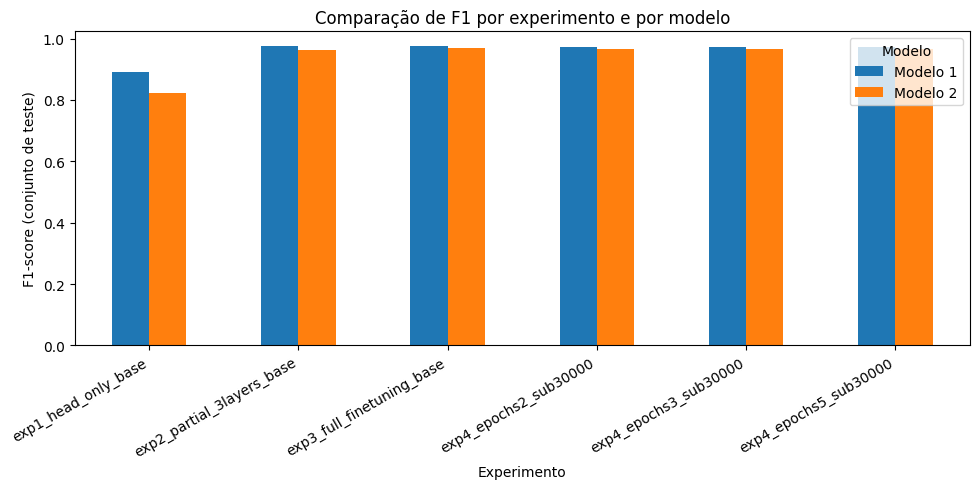

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
pivot_f1.plot(kind="bar", ax=ax)
ax.set_ylabel("F1-score (conjunto de teste)")
ax.set_xlabel("Experimento")
ax.set_title("Comparação de F1 por experimento e por modelo")
ax.legend(title="Modelo")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Exportar resultados para ajudar no  formulário do trabalho

In [ ]:
results_df.to_csv("resultados_experimentos_final.csv", index=False)
print("Resultados exportados para resultados_experimentos_final.csv "
      f"(o cache completo também está em {RESULTS_PATH}).")
results_df.head()

Resultados exportados para resultados_experimentos_final.csv (o cache completo também está em /content/drive/MyDrive/tp2_resultados_experimentos.csv).


,run_name,model_name,freeze_strategy,n_unfrozen_layers,total_layers,num_epochs,trainable_params,total_params,pct_trainable,n_train_examples,train_time_seconds,train_time_minutes,val_accuracy,val_f1,test_accuracy,test_precision,test_recall,test_f1,experiment,model_label
0,Modelo 1_exp1_head_only_base,neuralmind/bert-base-portuguese-cased,head_only,NaN,NaN,3,1538,108924674,0.00,74875,621.2,10.35,0.841361,0.893837,0.837887,0.834802,0.956769,0.891634,exp1_head_only_base,Modelo 1
1,Modelo 1_exp2_partial_3layers_base,neuralmind/bert-base-portuguese-cased,partial,3.0,12.0,3,21265154,108924674,19.52,74875,846.0,14.10,0.967350,0.976555,0.965158,0.976572,0.973367,0.974967,exp2_partial_3layers_base,Modelo 1
2,Modelo 1_exp3_full_finetuning_base,neuralmind/bert-base-portuguese-cased,full,NaN,NaN,3,108924674,108924674,100.00,74875,1677.4,27.96,0.969157,0.977843,0.965334,0.977303,0.972862,0.975077,exp3_full_finetuning_base,Modelo 1
3,Modelo 2_exp1_head_only_base,bert-base-multilingual-cased,head_only,NaN,NaN,3,1538,177854978,0.00,74875,631.3,10.52,0.699047,0.822021,0.699925,0.699929,0.996908,0.822430,exp1_head_only_base,Modelo 2
4,Modelo 2_exp2_partial_3layers_base,bert-base-multilingual-cased,partial,3.0,12.0,3,21265154,177854978,11.96,74875,853.3,14.22,0.953517,0.966499,0.950112,0.968593,0.959546,0.964048,exp2_partial_3layers_base,Modelo 2
